# TASK 1 => Project Setup

----

# 🇪🇬 ArabicSentimentLens
## Arabic Sentiment Analysis — End-to-End NLP Project

### Project Objective
Build an end-to-end NLP system that analyzes Arabic text and predicts its sentiment.

### Pipeline
- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Arabic Text Preprocessing
- Feature Extraction
- Model Training
- Model Comparison
- Evaluation
- Error Analysis
- Final Inference
- Model Export

### Target
Predict Arabic text sentiment as:
- Positive
- Negative

In [44]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Environment ready !")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Environment ready !
NumPy: 2.1.3
Pandas: 2.3.3


---

# TASK 2 => Load Dataset

---

# 1. Dataset Loading

في هذه المرحلة سنقوم بتحميل Dataset الخاصة بتحليل المشاعر باللغة العربية.

الـ Dataset تحتوي على عدد كبير من Arabic Reviews مع الـ Sentiment Label الخاص بكل Review.

هدفنا في المشروع هو استخدام نص الـ Review للتنبؤ بالمشاعر:

* Positive
* Negative

سنبدأ بفحص:

* حجم البيانات
* أسماء الأعمدة
* أول Samples
* أنواع البيانات
* توزيع الـ Labels


In [45]:
import os

# Show available Kaggle input datasets
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    for file in files[:10]:
        print("   ", file)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/abdallaellaithy
/kaggle/input/datasets/abdallaellaithy/330k-arabic-sentiment-reviews
    arabic_sentiment_reviews.csv


In [46]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/abdallaellaithy/330k-arabic-sentiment-reviews/arabic_sentiment_reviews.csv


#  2. Load & Inspect the Dataset

في هذه المرحلة سنقوم بتحميل الـ Arabic Sentiment Reviews Dataset وفهم الـ structure الأساسي للبيانات.

سنفحص:

* عدد الـ rows والـ columns
* أسماء الأعمدة
* أول samples
* Data types
* Missing values
* توزيع الـ sentiment labels

الهدف هو فهم البيانات قبل البدء في عملية الـ cleaning والـ preprocessing.


In [47]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/abdallaellaithy/330k-arabic-sentiment-reviews/arabic_sentiment_reviews.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully ")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSentiment Distribution:")
print(df.iloc[:, -1].value_counts())

Dataset loaded successfully 
Shape: (330000, 2)

Columns:
['label', 'content']

Data Types:
label       int64
content    object
dtype: object

First 5 rows:


,label,content
0,1,النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دا...
1,1,منتج جميل ، خدمة سيئة: لقد اشتريت زوجًا من الن...
2,1,جيد للأشياء الصغيرة: هذا يعمل بشكل جيد لالتقاط...
3,0,واهية للغاية: flimsyif للغاية ، فأنت تشتريه ، ...
4,1,Pop for Girls and Girly Boys ، والأشخاص الذين ...



Missing Values:
label      0
content    0
dtype: int64

Sentiment Distribution:
content
إن التعليم المسيحي للكنيسة الكاثوليكية يقول كل شيء: (من الفقرة 67) لا يمكن للإيمان المسيحي أن يقبل "الوحي" التي تدعي أنها تتجاوز أو تصحيح الوحي الذي هو المسيح هو الوفاء ، كما هو الحال في بعض الأديان غير المسيحية وأيضًا فيبعض الطوائف الحديثة التي تبني نفسها على مثل هذه "الوحي". (الفقرة 73) كشف الله عن نفسه بالكامل من خلال إرسال ابنه ، الذي أنشأ عهده إلى الأبد.الابن هو كلمة والده النهائية.لذلك لن يكون هناك المزيد من الوحي من بعده.                                                                                                                                                                                                                                                                                                                                                           2
متشنج - جيد دائمًا!: إذا كنت تحب لحوم البقر متشنج ، فستحب هذا المنتج.لقد طلبت ذلك من أجل 25 عامًا.الابن القديم الذي يتوقع حقيبة كب

---

#  3. Target Label Analysis

الـ Dataset تحتوي على عمودين:

* `content` => النص العربي الذي سيقوم الموديل بتحليله.
* `label` => الـ target الذي نريد من الموديل التنبؤ به.

قبل بناء أي Model، يجب أن نفهم قيم الـ labels وتوزيعها ونتأكد من عدم وجود مشكلة في الـ data.

سنقوم بفحص:

* Unique labels
* Number of samples لكل label
* النسبة المئوية لكل class


In [48]:
# Check unique labels
print("Unique labels:")
print(sorted(df["label"].unique()))

# Label distribution
label_counts = df["label"].value_counts().sort_index()

print("\nLabel Distribution:")
print(label_counts)

# Label percentages
label_percentages = (df["label"].value_counts(normalize=True).sort_index() * 100)

print("\nLabel Percentages:")
print(label_percentages.round(2))

# Basic text statistics
print("\nText Statistics:")
print("Average characters:", round(df["content"].str.len().mean(), 2))
print("Minimum characters:", df["content"].str.len().min())
print("Maximum characters:", df["content"].str.len().max())

Unique labels:
[np.int64(0), np.int64(1)]

Label Distribution:
label
0    163147
1    166853
Name: count, dtype: int64

Label Percentages:
label
0    49.44
1    50.56
Name: proportion, dtype: float64

Text Statistics:
Average characters: 362.39
Minimum characters: 2
Maximum characters: 1035


---

# 4. Text Cleaning

قبل تدريب الـ NLP models، سنقوم بتنظيف النصوص مع الحفاظ على المعلومات المهمة.

سنقوم بـ:

* إزالة HTML tags إن وجدت.
* إزالة URLs.
* توحيد بعض أشكال الحروف العربية.
* إزالة التشكيل.
* إزالة المسافات الزائدة.

لن نحذف الـ English characters، لأن الـ Dataset تحتوي على نصوص مختلطة عربي/English وقد تكون بعض الكلمات الإنجليزية مفيدة للتصنيف.


In [49]:
import re

def clean_arabic_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Normalize Arabic letters
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)

    # Remove Arabic diacritics
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)

    # Remove tatweel
    text = text.replace("ـ", "")

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_content"] = df["content"].apply(clean_arabic_text)

print("Original:")
print(df["content"].iloc[0])

print("\nCleaned:")
print(df["clean_content"].iloc[0])

Original:
النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة.زوجي وأنا على حد سواء لدينا زوج ونحن نحبهم!

Cleaned:
النعال المريحه: ارتدي هذه النعال كثيرا!فهي دافئه ومريحه وباسعار معقوله لجوده رائعه.زوجي وانا علي حد سواء لدينا زوج ونحن نحبهم!


                                        Fix Arabic Normalization

In [50]:
import re

def clean_arabic_text(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Normalize common Arabic letter variants
    text = re.sub(r"[إأآ]", "ا", text)

    # Remove Arabic diacritics
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)

    # Remove tatweel
    text = text.replace("ـ", "")

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_content"] = df["content"].apply(clean_arabic_text)

print("Original:")
print(df["content"].iloc[0])

print("\nCleaned:")
print(df["clean_content"].iloc[0])

Original:
النعال المريحة: أرتدي هذه النعال كثيرًا!فهي دافئة ومريحة وبأسعار معقولة لجودة رائعة.زوجي وأنا على حد سواء لدينا زوج ونحن نحبهم!

Cleaned:
النعال المريحة: ارتدي هذه النعال كثيرا!فهي دافئة ومريحة وباسعار معقولة لجودة رائعة.زوجي وانا على حد سواء لدينا زوج ونحن نحبهم!


---

# 4.2 Cleaning Quality Check

بعد تنظيف النصوص، سنقوم بعمل quality checks للتأكد من أن البيانات ما زالت صالحة للتدريب.

سنفحص:

* Empty texts
* Duplicate reviews
* Very short texts
* Missing labels

هذه الخطوة مهمة قبل تقسيم البيانات وتدريب الـ models.


In [51]:
# Empty cleaned texts
empty_texts = (df["clean_content"].str.len() == 0).sum()

# Duplicate texts
duplicate_texts = df["clean_content"].duplicated().sum()

# Very short texts
very_short = (df["clean_content"].str.len() < 3).sum()

# Missing labels
missing_labels = df["label"].isna().sum()

print("========== QUALITY CHECK ==========")
print(f"Empty texts       : {empty_texts}")
print(f"Duplicate texts   : {duplicate_texts}")
print(f"Very short texts  : {very_short}")
print(f"Missing labels    : {missing_labels}")

print("\nDataset shape:", df.shape)

========== QUALITY CHECK ==========
Empty texts       : 0
Duplicate texts   : 32
Very short texts  : 1
Missing labels    : 0

Dataset shape: (330000, 3)


#  5. Finalize Dataset & Train/Test Split

بعد التأكد من جودة البيانات، سنقوم بإزالة:

* Duplicate reviews
* Extremely short texts

ثم سنحدد:

* `X` => النصوص
* `y` => الـ sentiment labels

وسنقسم البيانات إلى:

* 80% Training
* 20% Testing

مع استخدام `stratify=y` للحفاظ على نفس توزيع الـ classes في المجموعتين.


In [52]:
# Remove duplicate reviews
df = df.drop_duplicates(subset="clean_content").copy()

# Remove extremely short texts
df = df[df["clean_content"].str.len() >= 3].copy()

# Reset index
df.reset_index(drop=True, inplace=True)

# Features and target
X = df["clean_content"]
y = df["label"]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("========== FINAL DATASET ==========")
print(f"Total samples : {len(df):,}")
print(f"Training      : {len(X_train):,}")
print(f"Testing       : {len(X_test):,}")

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(4))

print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))

========== FINAL DATASET ==========
Total samples : 329,967
Training      : 263,973
Testing       : 65,994

Training label distribution:
label
0    0.4944
1    0.5056
Name: proportion, dtype: float64

Testing label distribution:
label
0    0.4944
1    0.5056
Name: proportion, dtype: float64


----

#  6. TF-IDF Feature Extraction

النماذج التقليدية لا تستطيع التعامل مع النص الخام مباشرة، لذلك سنحوّل الـ reviews إلى numerical features باستخدام TF-IDF.

سنستخدم:

* `ngram_range=(1, 2)` => Unigrams + Bigrams
* `min_df=2` => تجاهل الكلمات النادرة جدًا
* `max_features=100000` => التحكم في حجم الـ feature space

الـ TF-IDF سيعطي وزنًا أعلى للكلمات المهمة داخل الـ corpus، وأقل للكلمات الشائعة جدًا.


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=100_000,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF created successfully ")

print("\nTraining matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape :", X_test_tfidf.shape)

print("\nNumber of features:", len(tfidf.vocabulary_))

TF-IDF created successfully 

Training matrix shape: (263973, 100000)
Testing matrix shape : (65994, 100000)

Number of features: 100000


---

# 7. Baseline Model — Logistic Regression

سنبدأ بـ Logistic Regression كـ baseline model.

الهدف ليس الوصول لأفضل نتيجة من أول محاولة، ولكن إنشاء benchmark واضح نقارن به النماذج الأقوى لاحقًا.

سنستخدم:

* `max_iter=1000` لضمان convergence.
* `n_jobs=-1` للاستفادة من المعالج.
* `class_weight=None` لأن الـ classes متوازنة تقريبًا.


In [54]:
from sklearn.linear_model import LogisticRegression
import time

start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

train_time = time.time() - start_time

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("========== LOGISTIC REGRESSION ==========")
print(f"Training time : {train_time:.2f} seconds")
print(f"Accuracy      : {lr_accuracy:.4f}")
print(f"Precision     : {lr_precision:.4f}")
print(f"Recall        : {lr_recall:.4f}")
print(f"F1-Score      : {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

========== LOGISTIC REGRESSION ==========
Training time : 4.76 seconds
Accuracy      : 0.9136
Precision     : 0.9140
Recall        : 0.9153
F1-Score      : 0.9146

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     32625
           1       0.91      0.92      0.91     33369

    accuracy                           0.91     65994
   macro avg       0.91      0.91      0.91     65994
weighted avg       0.91      0.91      0.91     65994



---------

# 8. Baseline Evaluation

بعد تدريب Logistic Regression، سنستخدم Confusion Matrix لفهم أداء النموذج بشكل أكثر تفصيلًا.

سنرى:

* True Negatives
* False Positives
* False Negatives
* True Positives

وده هيساعدنا نفهم نوع الأخطاء اللي النموذج بيعملها بدل الاعتماد على Accuracy فقط.


Confusion Matrix:
[[29750  2875]
 [ 2828 30541]]


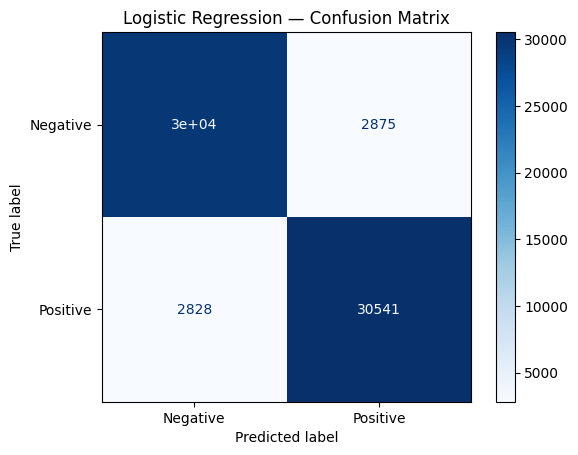

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Logistic Regression — Confusion Matrix")
plt.show()

----

## Error Analysis 

في هذه المرحلة سنحلل الـ **misclassified reviews**، وهي المراجعات التي توقع النموذج تصنيفًا خاطئًا لها.

سنركز على:

* استخراج الـ reviews التي أخطأ فيها Logistic Regression.
* مقارنة الـ **True Label** مع الـ **Predicted Label**.
* فحص أمثلة حقيقية من الأخطاء.
* محاولة فهم أسباب الخطأ مثل: **السخرية، النفي، الكلمات المختلطة، أو السياق المعقد**.

الهدف ليس فقط معرفة أن النموذج أخطأ، ولكن فهم **لماذا أخطأ**.


In [56]:
# Create a dataframe containing test reviews and predictions
error_analysis = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_lr
})

# Keep only misclassified reviews
errors = error_analysis[
    error_analysis["true_label"] != error_analysis["predicted_label"]
].copy()

print("========== ERROR ANALYSIS ==========")
print(f"Total test samples      : {len(error_analysis):,}")
print(f"Misclassified samples  : {len(errors):,}")
print(f"Error rate             : {len(errors) / len(error_analysis):.2%}")

print("\n========== ERROR TYPES ==========")
print("False Positives (0 → 1):",
      ((errors["true_label"] == 0) & (errors["predicted_label"] == 1)).sum())

print("False Negatives (1 → 0):",
      ((errors["true_label"] == 1) & (errors["predicted_label"] == 0)).sum())

========== ERROR ANALYSIS ==========
Total test samples      : 65,994
Misclassified samples  : 5,703
Error rate             : 8.64%

========== ERROR TYPES ==========
False Positives (0 → 1): 2875
False Negatives (1 → 0): 2828


----

## Inspect Misclassified Reviews

سنقوم الآن بعرض مجموعة من الـ **False Positives** والـ **False Negatives** لفهم الحالات التي أخطأ فيها النموذج.

* **False Positive (0 => 1):** المراجعة سلبية لكن النموذج توقع أنها إيجابية.
* **False Negative (1 => 0):** المراجعة إيجابية لكن النموذج توقع أنها سلبية.

سنستخدم أمثلة عشوائية حتى نحصل على صورة أفضل عن طبيعة الأخطاء.


In [57]:
print("========== FALSE POSITIVES (0 => 1) ==========")

fp_samples = errors[
    (errors["true_label"] == 0) &
    (errors["predicted_label"] == 1)
].sample(10, random_state=42)

for i, row in fp_samples.iterrows():
    print(f"\nTrue Label: {row['true_label']} | Predicted: {row['predicted_label']}")
    print(row["text"])


print("\n\n========== FALSE NEGATIVES (1 => 0) ==========")

fn_samples = errors[
    (errors["true_label"] == 1) &
    (errors["predicted_label"] == 0)
].sample(10, random_state=42)

for i, row in fn_samples.iterrows():
    print(f"\nTrue Label: {row['true_label']} | Predicted: {row['predicted_label']}")
    print(row["text"])

========== FALSE POSITIVES (0 => 1) ==========

True Label: 0 | Predicted: 1
لقد رايت اكثر رعبا: لقد احببت الفيلم وكل شيء ، لكنني رايت اكثر رعبا.مثل كيس من العظام ، كان ذلك مخيفا.التوتر والفزع ، وليس مخيف.

True Label: 0 | Predicted: 1
دمرت السلسلة باكملها: كنت وساكون دائما معجبا كبيرا بالمواسم الخارقة للطبيعة من واحد الى خمسة.النغمة العميقة والذات عن العائلة المجمعة مع الفكاهة المرحة وبعض رواية القصص المخيفة التي تم تقديمها لاحد افضل البرامج التلفزيونية التي رايتها على الاطلاق ، وربما سافعل ذلك.ولكن عندما ظهر هذا الموسم لاول مرة بعد ان تم تلخيص المؤامرة باكملها في الدفعة الخامسة ، شعرت كما لو ان الكتاب كانوا يصلون.سوف اعترف ان هناك بعض الحلقات الممتعة في هذا الموسم ، حيث سيكون هناك دائما عند مشاهدة خارقة للطبيعة (بغض النظر عن مدى سوء الموسم الكامل).بالنسبة لي ، كونه معجبا كبيرا بهذه السلسلة التي كنت عليها ، فقد خيب امالني حقا عندما غادر Kripke وكل شيء كان مجنونا بعض الشيء.الكل في الكل ، كنت افضلهم لانهاء العرض في الموسم الخامس.

True Label: 0 | Predicted: 1
ماذا مع الصبغة الاصفر المزع

----

## Feature Importance Analysis

سنحلل الآن أهم الـ TF-IDF features التي يعتمد عليها نموذج **Logistic Regression** في تحديد الـ sentiment.

* أعلى positive features => تميل إلى التصنيف **1**.
* أعلى negative features => تميل إلى التصنيف **0**.
* يساعدنا ذلك على فهم ما تعلّمه النموذج من البيانات.


In [58]:
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = lr_model.coef_[0]

# Most positive features
top_positive_idx = np.argsort(coefficients)[-20:][::-1]

# Most negative features
top_negative_idx = np.argsort(coefficients)[:20]

print("========== TOP POSITIVE FEATURES ==========")

for idx in top_positive_idx:
    print(f"{feature_names[idx]:<30} {coefficients[idx]:.4f}")

print("\n========== TOP NEGATIVE FEATURES ==========")

for idx in top_negative_idx:
    print(f"{feature_names[idx]:<30} {coefficients[idx]:.4f}")

========== TOP POSITIVE FEATURES ==========
رائع                           17.0466
ممتاز                          14.6534
رائعة                          12.1596
ممتازة                         11.0774
مثالي                          10.0833
جيد                            9.9170
مثالية                         7.6156
جيد جدا                        7.5950
مذهل                           7.5674
مذهلة                          7.2134
عظيم                           7.1235
من افضل                        7.0677
جميل                           7.0273
ممتع                           6.9336
الرائع                         6.7834
المفضل                         6.7403
ممتعة                          6.6707
قوي                            6.2531
نجوم                           6.1793
مدهش                           5.9459

========== TOP NEGATIVE FEATURES ==========
اسوا                           -18.1540
فظيع                           -14.6937
ممل                            -13.7583
لا يستحق                  

-------

## Advanced Model — Linear SVM

بعد بناء الـ baseline باستخدام **Logistic Regression**، سنجرب الآن نموذج **Linear Support Vector Machine (SVM)**.

يُستخدم Linear SVM بشكل واسع في **Text Classification** لأنه يتعامل بكفاءة مع البيانات عالية الأبعاد مثل TF-IDF.

سنقوم بتدريب النموذج على نفس الـ TF-IDF features ونقارن أداءه مع الـ Logistic Regression باستخدام:

* Accuracy
* Precision
* Recall
* F1-Score
* Training Time


In [59]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import time

start_time = time.time()

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

train_time_svm = time.time() - start_time

y_pred_svm = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("========== LINEAR SVM ==========")
print(f"Training time : {train_time_svm:.2f} seconds")
print(f"Accuracy      : {svm_accuracy:.4f}")
print(f"Precision     : {svm_precision:.4f}")
print(f"Recall        : {svm_recall:.4f}")
print(f"F1-Score      : {svm_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

========== LINEAR SVM ==========
Training time : 17.89 seconds
Accuracy      : 0.9142
Precision     : 0.9149
Recall        : 0.9155
F1-Score      : 0.9152

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     32625
           1       0.91      0.92      0.92     33369

    accuracy                           0.91     65994
   macro avg       0.91      0.91      0.91     65994
weighted avg       0.91      0.91      0.91     65994



----

##  Model Comparison

سنقارن الآن بين النماذج التي تم تدريبها باستخدام نفس الـ TF-IDF representation.

سنقارن:

* Accuracy
* Precision
* Recall
* F1-Score
* Training Time

الهدف هو تحديد الـ **best-performing model** قبل الانتقال إلى مرحلة الـ final model وdeployment.


In [60]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        svm_recall
    ],
    "F1-Score": [
        lr_f1,
        svm_f1
    ],
    "Training Time (sec)": [
        train_time,
        train_time_svm
    ]
})

comparison = comparison.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

print("========== MODEL COMPARISON ==========")
display(comparison.round(4))

========== MODEL COMPARISON ==========


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Linear SVM,0.9142,0.9149,0.9155,0.9152,17.8928
1,Logistic Regression,0.9136,0.9140,0.9153,0.9146,4.7609


-----

## Final Model Selection

بناءً على نتائج الـ model comparison، تم اختيار **Linear SVM** كنموذجنا النهائي.

حقق Linear SVM أفضل أداء على الـ test set:

* Accuracy: **91.42%**
* Precision: **91.49%**
* Recall: **91.55%**
* F1-Score: **91.52%**

سنستخدم هذا النموذج في مرحلة **Inference** للتنبؤ بالـ sentiment لمراجعات عربية جديدة.


In [61]:
def predict_sentiment(text):
    cleaned_text = clean_arabic_text(text)
    text_tfidf = tfidf.transform([cleaned_text])
    prediction = svm_model.predict(text_tfidf)[0]

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment


# Test with new Arabic reviews
test_reviews = [
    "الفيلم كان رائع جدا واستمتعت بكل دقيقة فيه",
    "الخدمة سيئة جدا ولن اشتري منهم مرة اخرى",
    "المنتج جيد والسعر مناسب جدا",
    "تجربة مملة وسيئة ولا انصح بها"
]

print("========== INFERENCE TESTING ==========")

for review in test_reviews:
    prediction = predict_sentiment(review)

    print(f"\nReview: {review}")
    print(f"Prediction: {prediction}")

========== INFERENCE TESTING ==========

Review: الفيلم كان رائع جدا واستمتعت بكل دقيقة فيه
Prediction: Positive

Review: الخدمة سيئة جدا ولن اشتري منهم مرة اخرى
Prediction: Negative

Review: المنتج جيد والسعر مناسب جدا
Prediction: Positive

Review: تجربة مملة وسيئة ولا انصح بها
Prediction: Negative


-----

## Save Final Model

سنقوم الآن بحفظ مكونات الـ NLP pipeline الأساسية:

* **Linear SVM** => النموذج النهائي.
* **TF-IDF Vectorizer** => لتحويل أي نص جديد إلى نفس الـ feature representation المستخدمة أثناء التدريب.

حفظ الاثنين معًا ضروري، لأن الـ model لا يستطيع التعامل مع النص الخام مباشرة.


In [62]:
import joblib
import os

# Save final model
model_path = "/kaggle/working/arabic_sentiment_svm.joblib"
vectorizer_path = "/kaggle/working/arabic_sentiment_tfidf.joblib"

joblib.dump(svm_model, model_path)
joblib.dump(tfidf, vectorizer_path)

print("========== FINAL FILES SAVED ==========")
print(f"Model     : {model_path}")
print(f"Vectorizer: {vectorizer_path}")

print("\nFile sizes:")
print(f"Model     : {os.path.getsize(model_path) / (1024**2):.2f} MB")
print(f"Vectorizer: {os.path.getsize(vectorizer_path) / (1024**2):.2f} MB")

========== FINAL FILES SAVED ==========
Model     : /kaggle/working/arabic_sentiment_svm.joblib
Vectorizer: /kaggle/working/arabic_sentiment_tfidf.joblib

File sizes:
Model     : 0.76 MB
Vectorizer: 4.31 MB


----

## Final Model Validation

سنقوم بتحميل الـ **saved model** والـ **saved TF-IDF vectorizer** من الملفات، ثم نستخدمهما في prediction على reviews جديدة.

هذه الخطوة تتأكد أن الـ model يمكن استخدامه بعد حفظه وإعادة تحميله بدون الحاجة إلى إعادة التدريب.


In [63]:
# Load saved artifacts
loaded_svm = joblib.load(model_path)
loaded_tfidf = joblib.load(vectorizer_path)


def predict_with_saved_model(text):
    cleaned_text = clean_arabic_text(text)
    text_tfidf = loaded_tfidf.transform([cleaned_text])
    prediction = loaded_svm.predict(text_tfidf)[0]

    return "Positive" if prediction == 1 else "Negative"


# Validation reviews
validation_reviews = [
    "الفيلم رائع وممتع جدا",
    "التجربة سيئة ومخيبة للامال",
    "المنتج ممتاز وسأشتريه مرة اخرى"
]

print("========== SAVED MODEL VALIDATION ==========")

for review in validation_reviews:
    print(f"\nReview: {review}")
    print(f"Prediction: {predict_with_saved_model(review)}")

========== SAVED MODEL VALIDATION ==========

Review: الفيلم رائع وممتع جدا
Prediction: Positive

Review: التجربة سيئة ومخيبة للامال
Prediction: Negative

Review: المنتج ممتاز وسأشتريه مرة اخرى
Prediction: Positive


-----

                                         new Session

----

## Exploratory Data Analysis — Visualizations

في هذا القسم سنعرض أهم الـ visualizations لفهم طبيعة البيانات قبل وبعد الـ preprocessing.

سنركز على:

* **Sentiment Distribution:** لمعرفة مدى توازن الـ classes.
* **Review Length Distribution:** لفهم أطوال الـ Arabic reviews.
* **Text Statistics:** لتلخيص خصائص النصوص المستخدمة في المشروع.

هذه الرسومات تساعدنا على فهم الـ dataset وتوثيق خصائصها بشكل واضح.


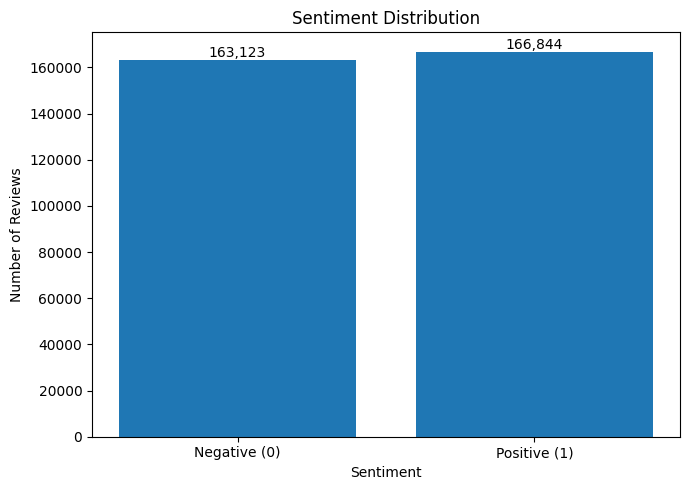

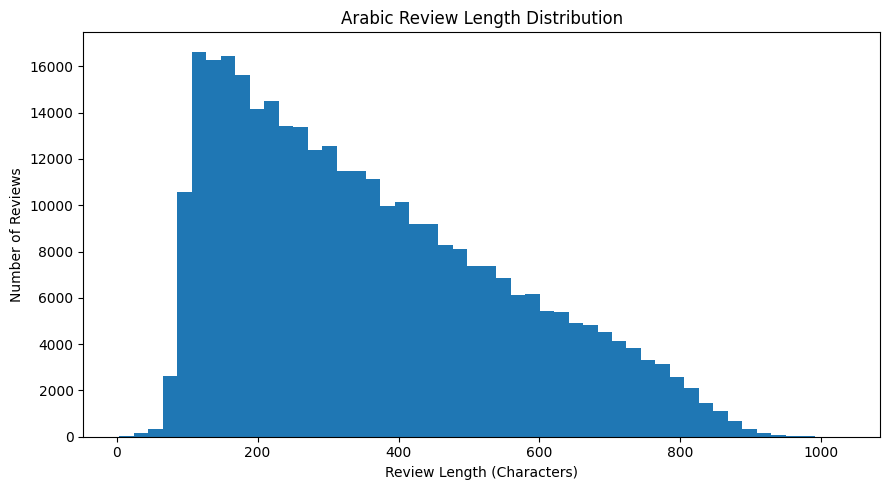

========== TEXT STATISTICS ==========
Total reviews      : 329,967
Average length     : 360.26
Median length      : 323.00
Minimum length     : 4
Maximum length     : 1032
Standard deviation : 196.78

========== LABEL DISTRIBUTION ==========
Negative  : 163,123 (49.44%)
Positive  : 166,844 (50.56%)


In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate review lengths
df["review_length"] = df["clean_content"].str.len()

# ==============================
# 1. Sentiment Distribution
# ==============================

label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Negative (0)", "Positive (1)"],
    label_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, value in enumerate(label_counts.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


# ==============================
# 2. Review Length Distribution
# ==============================

plt.figure(figsize=(9, 5))
plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Arabic Review Length Distribution")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()


# ==============================
# 3. Text Statistics
# ==============================

print("========== TEXT STATISTICS ==========")

print(f"Total reviews      : {len(df):,}")
print(f"Average length     : {df['review_length'].mean():.2f}")
print(f"Median length      : {df['review_length'].median():.2f}")
print(f"Minimum length     : {df['review_length'].min()}")
print(f"Maximum length     : {df['review_length'].max()}")
print(f"Standard deviation : {df['review_length'].std():.2f}")

print("\n========== LABEL DISTRIBUTION ==========")

for label, count in label_counts.items():
    percentage = count / len(df) * 100
    sentiment = "Negative" if label == 0 else "Positive"
    print(f"{sentiment:<10}: {count:,} ({percentage:.2f}%)")

-----

## Final Model Evaluation — Model Comparison

سنقوم الآن بإنشاء visualization نهائي لمقارنة أداء الـ models.

المقارنة تشمل:

* Accuracy
* Precision
* Recall
* F1-Score

الهدف هو توضيح الفرق بين الـ **Logistic Regression** والـ **Linear SVM** بصريًا، وتحديد النموذج الأفضل بشكل واضح.


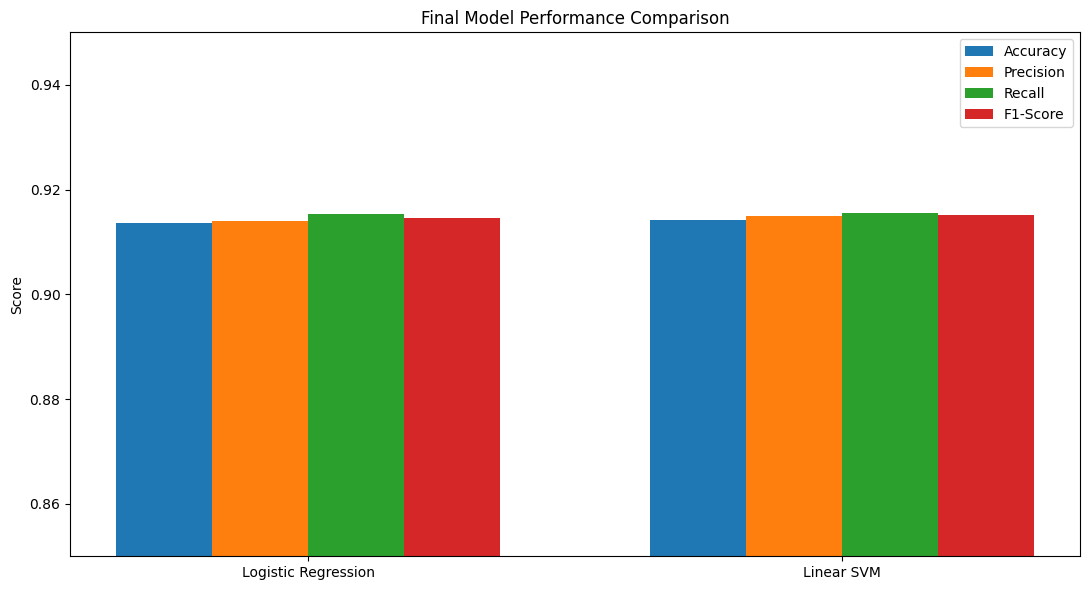

In [66]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression", "Linear SVM"]

accuracy_scores = [lr_accuracy, svm_accuracy]
precision_scores = [lr_precision, svm_precision]
recall_scores = [lr_recall, svm_recall]
f1_scores = [lr_f1, svm_f1]

x = np.arange(len(models))
width = 0.18

plt.figure(figsize=(11, 6))

plt.bar(x - 1.5 * width, accuracy_scores, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision_scores, width, label="Precision")
plt.bar(x + 0.5 * width, recall_scores, width, label="Recall")
plt.bar(x + 1.5 * width, f1_scores, width, label="F1-Score")

plt.xticks(x, models)
plt.ylim(0.85, 0.95)
plt.ylabel("Score")
plt.title("Final Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

---

## Final Model — Confusion Matrix

بعد اختيار **Linear SVM** كنموذجنا النهائي، سنقوم بتحليل أخطائه باستخدام **Confusion Matrix**.

ستوضح لنا:

* **True Negatives (TN)**
* **False Positives (FP)**
* **False Negatives (FN)**
* **True Positives (TP)**

وستساعدنا على فهم أداء النموذج النهائي في التمييز بين الـ **Positive** والـ **Negative** reviews.


========== SVM CONFUSION MATRIX ==========
[[29783  2842]
 [ 2819 30550]]

TN: 29783
FP: 2842
FN: 2819
TP: 30550


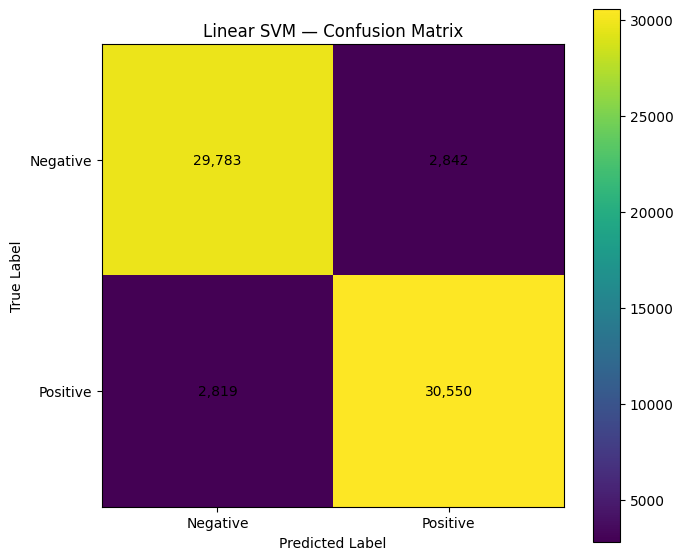

In [67]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("========== SVM CONFUSION MATRIX ==========")
print(cm_svm)

print("\nTN:", cm_svm[0, 0])
print("FP:", cm_svm[0, 1])
print("FN:", cm_svm[1, 0])
print("TP:", cm_svm[1, 1])


# Visualization
plt.figure(figsize=(7, 6))

plt.imshow(cm_svm)

plt.title("Linear SVM — Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{cm_svm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

----

# Project Summary & Conclusion

##  Project Overview

**ArabicSentimentLens** is an end-to-end Arabic Sentiment Analysis system designed to classify Arabic reviews into:

* **Negative (0)**
* **Positive (1)**

The project uses classical NLP techniques combined with machine learning to build an efficient Arabic text classification pipeline.

---

##  Dataset

* Total reviews after cleaning: **329,967**
* Negative reviews: **163,123 (49.44%)**
* Positive reviews: **166,844 (50.56%)**
* Average review length: **360.26 characters**
* Train samples: **263,973**
* Test samples: **65,994**

The dataset is well balanced between the two sentiment classes.

---

##  Text Preprocessing

The preprocessing pipeline included:

* HTML removal
* URL removal
* Arabic letter normalization
* Diacritics removal
* Tatweel removal
* Whitespace normalization
* Duplicate removal
* Very short review removal

---

##  Feature Extraction

Reviews were converted into numerical representations using **TF-IDF** with:

* Unigrams + Bigrams
* `min_df = 2`
* Maximum **100,000 features**
* Sublinear TF scaling

---

##  Models

Two machine learning models were evaluated:

1. **Logistic Regression**
2. **Linear SVM**

### Final Results

| Model               |   Accuracy |  Precision |     Recall |   F1-Score |
| ------------------- | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression |     91.36% |     91.40% |     91.53% |     91.46% |
| **Linear SVM**      | **91.42%** | **91.49%** | **91.55%** | **91.52%** |

###  Final Model

**Linear SVM** was selected as the final model because it achieved the best overall performance across the main evaluation metrics.

---

##  Error Analysis

The error analysis showed that the model can struggle with:

* Sarcasm and irony
* Mixed positive and negative sentiment
* Negation
* Long reviews containing conflicting opinions
* Noisy or translated text
* Context-dependent sentiment

These limitations are expected from a TF-IDF based classical NLP approach because it does not fully understand the semantic context of the entire sentence.

---

##  Inference

The final model successfully classified new Arabic reviews during inference testing.

The saved model and TF-IDF vectorizer were also loaded again and successfully validated, confirming that the saved pipeline can be reused without retraining.

---

##  Saved Artifacts

The final pipeline consists of:

* `arabic_sentiment_svm.joblib`
* `arabic_sentiment_tfidf.joblib`

---

##  Limitations

Although the model achieves over **91% F1-Score**, it has several limitations:

* TF-IDF does not capture deep semantic relationships.
* Sarcasm remains difficult to detect.
* Context across long reviews can be lost.
* Arabic dialect variations may affect performance.
* The model is limited to binary sentiment classification.

---

##  Future Improvements

Possible improvements include:

* Arabic-specific tokenization and stemming/lemmatization.
* Word embeddings such as **Word2Vec** or **FastText**.
* Transformer-based Arabic models.
* Fine-tuning models such as **AraBERT**.
* Better handling of Arabic dialects.
* Deployment through an interactive web application.

---

##  Final Conclusion

The project successfully demonstrates a complete Arabic NLP sentiment analysis pipeline, starting from raw reviews and ending with a validated, reusable machine learning model.

The final **Linear SVM + TF-IDF** pipeline achieved an **F1-Score of 91.52%** and was successfully tested on new Arabic reviews.


----

# ArabicSentimentLens — Model Demo

هذه الواجهة تمثل النسخة التفاعلية من مشروع **ArabicSentimentLens**.

يمكن للمستخدم إدخال أي Arabic review، ثم تمريرها خلال نفس الـpipeline المستخدمة أثناء تدريب النموذج:

**Arabic Text → Cleaning → TF-IDF → Linear SVM → Sentiment Prediction**

### Model

* **Algorithm:** Linear SVM
* **Feature Extraction:** TF-IDF
* **N-grams:** Unigrams + Bigrams
* **Features:** 100,000
* **Accuracy:** 91.42%
* **F1-Score:** 91.52%

### Dataset

* **329,967 Arabic reviews**
* Balanced Positive / Negative classes

> الهدف من هذه الصفحة هو اختبار النموذج عمليًا قبل نشر المشروع على GitHub وKaggle وLinkedIn.


In [68]:
import gradio as gr

# ============================================
            # Prediction Function
# ============================================

def predict_sentiment_demo(text):
    if not text or not text.strip():
        return " Please enter an Arabic review."

    cleaned_text = clean_arabic_text(text)
    text_tfidf = loaded_tfidf.transform([cleaned_text])
    prediction = loaded_svm.predict(text_tfidf)[0]

    if prediction == 1:
        return " Positive Sentiment"
    else:
        return " Negative Sentiment"


# ============================================
       # Professional Gradio Interface
# ============================================

with gr.Blocks(title="ArabicSentimentLens") as demo:

    gr.Markdown(
        """
        #  ArabicSentimentLens

        ### Arabic Sentiment Analysis using TF-IDF + Linear SVM

        Enter an Arabic review and let the trained machine learning model
        predict whether the sentiment is **Positive** or **Negative**.
        """
    )

    gr.Markdown(
        """
        ##  How the Model Works

        **Arabic Review**
        ↓
        **Text Cleaning**
        ↓
        **TF-IDF (100K Features)**
        ↓
        **Linear SVM**
        ↓
        **Sentiment Prediction**
        """
    )

    with gr.Row():

        with gr.Column(scale=2):
            review_input = gr.Textbox(
                lines=6,
                placeholder="اكتب تقييم باللغة العربية هنا...",
                label=" Arabic Review"
            )

            predict_button = gr.Button(
                " Predict Sentiment",
                variant="primary"
            )

        with gr.Column(scale=1):
            prediction_output = gr.Textbox(
                label=" Prediction",
                interactive=False
            )

    predict_button.click(
        fn=predict_sentiment_demo,
        inputs=review_input,
        outputs=prediction_output
    )

    gr.Markdown("##  Model Performance")

    gr.Markdown(
        """
        | Metric | Linear SVM |
        |---|---:|
        | Accuracy | **91.42%** |
        | Precision | **91.49%** |
        | Recall | **91.55%** |
        | F1-Score | **91.52%** |
        """
    )

    gr.Markdown(
        """
        ##  Project Information

        **Dataset:** 330K Arabic Sentiment Reviews Dataset

        **Final Dataset:** 329,967 reviews

        **Feature Extraction:** TF-IDF

        **Model:** Linear SVM

        **Task:** Binary Arabic Sentiment Classification

        **Classes:**
        -  Positive
        -  Negative
        """
    )

    gr.Markdown("##  Try Example Reviews")

    gr.Examples(
        examples=[
            ["الفيلم رائع جدا واستمتعت بكل دقيقة فيه"],
            ["الخدمة سيئة جدا ولن اشتري منهم مرة اخرى"],
            ["المنتج ممتاز وسأشتريه مرة اخرى"],
            ["تجربة مملة وسيئة ولا انصح بها"],
            ["المطعم جميل جدا والطعام كان ممتاز"],
            ["التجربة كانت سيئة ولن اكررها"]
        ],
        inputs=review_input
    )

    gr.Markdown(
        """
        ---
        
        ### ArabicSentimentLens
        Built with **Python · Scikit-learn · TF-IDF · Linear SVM · Gradio**
        """
    )


demo.launch(
    share=True
)

* Running on local URL:  http://127.0.0.1:7863
* Running on public URL: https://fe687be256aa316a64.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


----

# Deployment Preparation

في هذا القسم سنجهز ملفات المشروع اللازمة لنشر **ArabicSentimentLens** كـInteractive Web App.

سيتم فصل الـDemo عن بيئة Kaggle بحيث يمكن تشغيلها بشكل مستقل على **Hugging Face Spaces**.

### Deployment Files

* `app.py` => واجهة التطبيق والـinference logic
* `requirements.txt` => المكتبات المطلوبة
* `arabic_sentiment_svm.joblib` => النموذج المدرب
* `arabic_sentiment_tfidf.joblib` => TF-IDF vectorizer

بعد تجهيز الملفات واختبارها، سننشر التطبيق ونحصل على **Permanent Public URL**.


In [69]:
# ============================================
          # Create Deployment Files
# ============================================

import os
import shutil

deployment_dir = "/kaggle/working/ArabicSentimentLens"

os.makedirs(deployment_dir, exist_ok=True)

# Copy trained model artifacts
shutil.copy(
    "/kaggle/working/arabic_sentiment_svm.joblib",
    f"{deployment_dir}/arabic_sentiment_svm.joblib"
)

shutil.copy(
    "/kaggle/working/arabic_sentiment_tfidf.joblib",
    f"{deployment_dir}/arabic_sentiment_tfidf.joblib"
)

print("Deployment directory created:")
print(deployment_dir)

print("\nFiles:")
for file in os.listdir(deployment_dir):
    print(" -", file)

Deployment directory created:
/kaggle/working/ArabicSentimentLens

Files:
 - app.py
 - arabic_sentiment_tfidf.joblib
 - index.html
 - arabic_sentiment_svm.joblib
 - requirements.txt
 - model.json


----

# Deployment App — `app.py`

سننشئ الآن ملف التطبيق الرئيسي الذي يحتوي على:

* تحميل الـsaved TF-IDF vectorizer.
* تحميل الـsaved Linear SVM model.
* نفس Arabic text cleaning المستخدمة أثناء التدريب.
* Prediction function.
* واجهة Gradio الاحترافية.


In [70]:
# ============
# Create app.py
# ============

app_code = r'''
import re
import joblib
import gradio as gr


# ====================
# Load Saved Artifacts
# ====================

MODEL_PATH = "arabic_sentiment_svm.joblib"
VECTORIZER_PATH = "arabic_sentiment_tfidf.joblib"

model = joblib.load(MODEL_PATH)
tfidf = joblib.load(VECTORIZER_PATH)


# ====================
# Arabic Text Cleaning
# ====================

def clean_arabic_text(text):
    text = str(text)

    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[إأآ]", "ا", text)
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)
    text = text.replace("ـ", "")
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ===================
# Prediction Function
# ===================

def predict_sentiment(text):

    if not text or not text.strip():
        return " Please enter an Arabic review."

    cleaned_text = clean_arabic_text(text)

    text_tfidf = tfidf.transform([cleaned_text])

    prediction = model.predict(text_tfidf)[0]

    if prediction == 1:
        return " Positive Sentiment"
    else:
        return " Negative Sentiment"


# ================
# Gradio Interface
# ================

with gr.Blocks(title="ArabicSentimentLens") as demo:

    gr.Markdown(
        """
        #  ArabicSentimentLens

        ### Arabic Sentiment Analysis using TF-IDF + Linear SVM

        Enter an Arabic review and let the trained machine learning
        model predict whether the sentiment is **Positive** or **Negative**.
        """
    )

    gr.Markdown(
        """
        ##  How the Model Works

        **Arabic Review**
        ↓
        **Text Cleaning**
        ↓
        **TF-IDF (100K Features)**
        ↓
        **Linear SVM**
        ↓
        **Sentiment Prediction**
        """
    )

    with gr.Row():

        with gr.Column(scale=2):

            review_input = gr.Textbox(
                lines=6,
                placeholder="اكتب تقييم باللغة العربية هنا...",
                label=" Arabic Review"
            )

            predict_button = gr.Button(
                " Predict Sentiment",
                variant="primary"
            )

        with gr.Column(scale=1):

            prediction_output = gr.Textbox(
                label=" Prediction",
                interactive=False
            )

    predict_button.click(
        fn=predict_sentiment,
        inputs=review_input,
        outputs=prediction_output
    )

    gr.Markdown("##  Model Performance")

    gr.Markdown(
        """
        | Metric | Linear SVM |
        |---|---:|
        | Accuracy | **91.42%** |
        | Precision | **91.49%** |
        | Recall | **91.55%** |
        | F1-Score | **91.52%** |
        """
    )

    gr.Markdown(
        """
        ## Project Information

        **Dataset:** 330K Arabic Sentiment Reviews Dataset

        **Final Dataset:** 329,967 reviews

        **Feature Extraction:** TF-IDF

        **Model:** Linear SVM

        **Task:** Binary Arabic Sentiment Classification

        **Classes:**
        -  Positive
        -  Negative
        """
    )

    gr.Markdown("##  Try Example Reviews")

    gr.Examples(
        examples=[
            ["الفيلم رائع جدا واستمتعت بكل دقيقة فيه"],
            ["الخدمة سيئة جدا ولن اشتري منهم مرة اخرى"],
            ["المنتج ممتاز وسأشتريه مرة اخرى"],
            ["تجربة مملة وسيئة ولا انصح بها"],
            ["المطعم جميل جدا والطعام كان ممتاز"],
            ["التجربة كانت سيئة ولن اكررها"]
        ],
        inputs=review_input
    )

    gr.Markdown(
        """
        ---
        
        ### ArabicSentimentLens

        Built with **Python · Scikit-learn · TF-IDF · Linear SVM · Gradio**
        """
    )


# ==========
# Launch App
# ==========

demo.launch()
'''

app_path = "/kaggle/working/ArabicSentimentLens/app.py"

with open(app_path, "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully!")
print(app_path)
print(f"\nFile size: {os.path.getsize(app_path) / 1024:.2f} KB")

app.py created successfully!
/kaggle/working/ArabicSentimentLens/app.py

File size: 3.87 KB


----

# Deployment Dependencies

سنحدد الآن جميع الـPython libraries المطلوبة لتشغيل **ArabicSentimentLens** خارج بيئة Kaggle.

الـdeployment يحتاج فقط إلى:

* Gradio => واجهة التطبيق
* scikit-learn => تشغيل Linear SVM وTF-IDF
* joblib => تحميل الـsaved model والـvectorizer


In [71]:
# =======================
# Create requirements.txt
# =======================

requirements = """gradio
scikit-learn
joblib
"""

requirements_path = "/kaggle/working/ArabicSentimentLens/requirements.txt"

with open(requirements_path, "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully!")
print(requirements_path)

print("\nContents:")
print(requirements)

requirements.txt created successfully!
/kaggle/working/ArabicSentimentLens/requirements.txt

Contents:
gradio
scikit-learn
joblib



---

# Final Deployment Package Check

قبل نشر **ArabicSentimentLens**، سنراجع الـdeployment package بالكامل.

### Required Files

* `app.py` — Application & inference logic
* `requirements.txt` — Python dependencies
* `arabic_sentiment_svm.joblib` — Trained Linear SVM
* `arabic_sentiment_tfidf.joblib` — TF-IDF vectorizer

إذا كانت الملفات الأربعة موجودة، فالـpackage جاهزة للـdeployment.


In [72]:
# =============================
# Final Deployment Package Check
# =============================

import os

deployment_dir = "/kaggle/working/ArabicSentimentLens"

required_files = [
    "app.py",
    "requirements.txt",
    "arabic_sentiment_svm.joblib",
    "arabic_sentiment_tfidf.joblib"
]

print("=" * 50)
print("ARABICSENTIMENTLENS — DEPLOYMENT PACKAGE")
print("=" * 50)

all_files_exist = True

for filename in required_files:
    path = os.path.join(deployment_dir, filename)

    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f" {filename:<35} {size_kb:,.2f} KB")
    else:
        print(f" {filename:<35} MISSING")
        all_files_exist = False

print("=" * 50)

if all_files_exist:
    print("STATUS:  READY FOR DEPLOYMENT")
else:
    print("STATUS:  PACKAGE INCOMPLETE")

ARABICSENTIMENTLENS — DEPLOYMENT PACKAGE
 app.py                              3.87 KB
 requirements.txt                    0.03 KB
 arabic_sentiment_svm.joblib         781.96 KB
 arabic_sentiment_tfidf.joblib       4,412.91 KB
STATUS:  READY FOR DEPLOYMENT


----

# Static Deployment — Browser Inference

لأن الـHugging Face Static Space لا تشغّل Python مباشرة، سنحوّل مكونات الـMachine Learning model إلى صيغة يمكن تشغيلها داخل المتصفح.

سيتم تصدير:

* TF-IDF vocabulary
* TF-IDF IDF weights
* Linear SVM coefficients
* Linear SVM intercept

وبذلك يمكن تنفيذ نفس الـinference pipeline باستخدام JavaScript بدون Python backend.


In [73]:
# ============================================
   # Export TF-IDF + Linear SVM for Browser
# ============================================

import json
import numpy as np
import os

deployment_dir = "/kaggle/working/ArabicSentimentLens"

# ------------------------
# Extract model parameters
# ------------------------

# Convert NumPy types to native Python types
vocabulary = {
    str(term): int(index)
    for term, index in tfidf.vocabulary_.items()
}

idf = tfidf.idf_.astype(float).tolist()

svm_coefficients = svm_model.coef_[0].astype(float).tolist()

svm_intercept = float(svm_model.intercept_[0])

# ---------------------
# Prepare browser model
# ---------------------

browser_model = {
    "vocabulary": vocabulary,
    "idf": idf,
    "svm_coefficients": svm_coefficients,
    "svm_intercept": svm_intercept,
    "n_features": len(idf),
    "ngram_range": [1, 2],
    "sublinear_tf": True,
    "norm": "l2"
}

# ---------
# Save JSON
# ---------

model_json_path = os.path.join(
    deployment_dir,
    "model.json"
)

with open(model_json_path, "w", encoding="utf-8") as f:
    json.dump(
        browser_model,
        f,
        ensure_ascii=False,
        separators=(",", ":")
    )

# ------
# Report
# ------

file_size_mb = os.path.getsize(model_json_path) / (1024 ** 2)

print("=" * 60)
print("BROWSER MODEL EXPORT")
print("=" * 60)

print(f"Vocabulary size     : {len(vocabulary):,}")
print(f"TF-IDF features     : {len(idf):,}")
print(f"SVM coefficients    : {len(svm_coefficients):,}")
print(f"SVM intercept       : {svm_intercept:.6f}")
print(f"Exported file       : {model_json_path}")
print(f"File size           : {file_size_mb:.2f} MB")

print("=" * 60)
print("STATUS:  MODEL READY FOR BROWSER INFERENCE")



BROWSER MODEL EXPORT
Vocabulary size     : 100,000
TF-IDF features     : 100,000
SVM coefficients    : 100,000
SVM intercept       : 0.022549
Exported file       : /kaggle/working/ArabicSentimentLens/model.json
File size           : 5.93 MB
STATUS:  MODEL READY FOR BROWSER INFERENCE


----

# ArabicSentimentLens — Static Web App

سننشئ الآن واجهة الويب الخاصة بالـStatic Deployment.

التطبيق سيعمل بالكامل داخل الـbrowser بدون Python backend.

### Browser Pipeline

**Arabic Review → Text Cleaning => TF-IDF => Linear SVM => Prediction**

وسيتم تحميل الـmodel parameters من `model.json` عند فتح الصفحة.


In [74]:
# ================
# Create index.html
# ================

html_code = r'''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>ArabicSentimentLens</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f7fb;
            color: #1f2937;
        }

        .container {
            max-width: 1000px;
            margin: auto;
            padding: 40px 20px;
        }

        .hero {
            background: white;
            border-radius: 20px;
            padding: 35px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.08);
            margin-bottom: 25px;
        }

        h1 {
            margin-top: 0;
            font-size: 38px;
        }

        .subtitle {
            font-size: 18px;
            color: #6b7280;
            line-height: 1.6;
        }

        .pipeline {
            margin-top: 25px;
            padding: 18px;
            background: #f1f5f9;
            border-radius: 12px;
            font-weight: bold;
            text-align: center;
        }

        .card {
            background: white;
            border-radius: 20px;
            padding: 30px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.06);
            margin-bottom: 25px;
        }

        textarea {
            width: 100%;
            min-height: 150px;
            padding: 16px;
            border: 1px solid #d1d5db;
            border-radius: 12px;
            font-size: 17px;
            resize: vertical;
            direction: rtl;
        }

        button {
            margin-top: 15px;
            width: 100%;
            padding: 15px;
            border: none;
            border-radius: 12px;
            background: #2563eb;
            color: white;
            font-size: 17px;
            font-weight: bold;
            cursor: pointer;
        }

        button:hover {
            background: #1d4ed8;
        }

        #result {
            margin-top: 20px;
            padding: 18px;
            border-radius: 12px;
            text-align: center;
            font-size: 22px;
            font-weight: bold;
            display: none;
        }

        .positive {
            background: #dcfce7;
            color: #166534;
        }

        .negative {
            background: #fee2e2;
            color: #991b1b;
        }

        .loading {
            background: #e0f2fe;
            color: #075985;
        }

        .metrics {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 15px;
        }

        .metric {
            padding: 20px;
            background: #f8fafc;
            border-radius: 12px;
            text-align: center;
        }

        .metric strong {
            display: block;
            font-size: 25px;
            margin-bottom: 5px;
        }

        .metric span {
            color: #6b7280;
        }

        .example {
            padding: 12px;
            margin-top: 10px;
            border-radius: 10px;
            background: #f8fafc;
            cursor: pointer;
        }

        .example:hover {
            background: #e2e8f0;
        }

        footer {
            text-align: center;
            color: #6b7280;
            padding: 20px;
        }

        @media (max-width: 700px) {
            .metrics {
                grid-template-columns: repeat(2, 1fr);
            }

            h1 {
                font-size: 30px;
            }
        }
    </style>
</head>

<body>

<div class="container">

    <div class="hero">

        <h1> ArabicSentimentLens</h1>

        <p class="subtitle">
            Arabic Sentiment Analysis using
            <strong>TF-IDF + Linear SVM</strong>.
        </p>

        <div class="pipeline">
            Arabic Review → Text Cleaning → TF-IDF → Linear SVM → Prediction
        </div>

    </div>


    <div class="card">

        <h2> Test the Model</h2>

        <textarea
            id="review"
            placeholder="اكتب تقييم باللغة العربية هنا..."
        ></textarea>

        <button onclick="predictSentiment()">
             Predict Sentiment
        </button>

        <div id="result"></div>

    </div>


    <div class="card">

        <h2> Model Performance</h2>

        <div class="metrics">

            <div class="metric">
                <strong>91.42%</strong>
                <span>Accuracy</span>
            </div>

            <div class="metric">
                <strong>91.49%</strong>
                <span>Precision</span>
            </div>

            <div class="metric">
                <strong>91.55%</strong>
                <span>Recall</span>
            </div>

            <div class="metric">
                <strong>91.52%</strong>
                <span>F1-Score</span>
            </div>

        </div>

    </div>


    <div class="card">

        <h2> Project Information</h2>

        <p><strong>Dataset:</strong> 330K Arabic Sentiment Reviews Dataset</p>

        <p><strong>Final Dataset:</strong> 329,967 reviews</p>

        <p><strong>Feature Extraction:</strong> TF-IDF</p>

        <p><strong>Features:</strong> 100,000</p>

        <p><strong>Model:</strong> Linear SVM</p>

        <p><strong>Task:</strong> Binary Arabic Sentiment Classification</p>

    </div>


    <div class="card">

        <h2> Example Reviews</h2>

        <div
            class="example"
            onclick="useExample(this)"
        >
            الفيلم رائع جدا واستمتعت بكل دقيقة فيه
        </div>

        <div
            class="example"
            onclick="useExample(this)"
        >
            الخدمة سيئة جدا ولن اشتري منهم مرة اخرى
        </div>

        <div
            class="example"
            onclick="useExample(this)"
        >
            المنتج ممتاز وسأشتريه مرة اخرى
        </div>

        <div
            class="example"
            onclick="useExample(this)"
        >
            تجربة مملة وسيئة ولا انصح بها
        </div>

    </div>


    <footer>
        ArabicSentimentLens · Python · Scikit-learn · TF-IDF · Linear SVM
    </footer>

</div>


<script>

let model = null;


// ==========
// Load Model
// ==========

async function loadModel() {

    const response = await fetch("model.json");

    model = await response.json();

    console.log("ArabicSentimentLens model loaded.");
    console.log("Features:", model.n_features);
}


// ====================
// Arabic Text Cleaning
// ====================

function cleanArabicText(text) {

    text = String(text);

    text = text.replace(/<[^>]+>/g, " ");

    text = text.replace(
        /https?:\/\/\S+|www\.\S+/g,
        " "
    );

    text = text.replace(
        /[إأآ]/g,
        "ا"
    );

    text = text.replace(
        /[\u064B-\u065F\u0670]/g,
        ""
    );

    text = text.replace(
        /ـ/g,
        ""
    );

    text = text.replace(
        /\s+/g,
        " "
    );

    return text.trim();
}


// ================
// Generate N-Grams
// ================

function generateNgrams(tokens) {

    const ngrams = [];

    for (let i = 0; i < tokens.length; i++) {

        ngrams.push(tokens[i]);

        if (i < tokens.length - 1) {

            ngrams.push(
                tokens[i] + " " + tokens[i + 1]
            );

        }

    }

    return ngrams;
}


// ======
// TF-IDF
// ======

function calculateTFIDF(text) {

    const tokens = text.split(/\s+/);

    const ngrams = generateNgrams(tokens);

    const counts = {};

    for (const term of ngrams) {

        if (model.vocabulary.hasOwnProperty(term)) {

            counts[term] = (counts[term] || 0) + 1;

        }

    }

    const vector = new Float64Array(model.n_features);

    const totalTerms = ngrams.length;

    for (const term in counts) {

        const index = model.vocabulary[term];

        const count = counts[term];

        let tf = count / totalTerms;

        tf = Math.log1p(tf);

        vector[index] = tf * model.idf[index];

    }


    // L2 normalization

    let norm = 0;

    for (let i = 0; i < vector.length; i++) {

        norm += vector[i] * vector[i];

    }

    norm = Math.sqrt(norm);

    if (norm > 0) {

        for (let i = 0; i < vector.length; i++) {

            vector[i] /= norm;

        }

    }

    return vector;
}


// =====================
// Linear SVM Prediction
// =====================

function predictSentiment() {

    const input = document.getElementById("review");

    const result = document.getElementById("result");

    const text = input.value.trim();


    if (!text) {

        result.style.display = "block";

        result.className = "loading";

        result.textContent =
            " Please enter an Arabic review.";

        return;

    }


    if (!model) {

        result.style.display = "block";

        result.className = "loading";

        result.textContent =
            " Model is still loading...";

        return;

    }


    const cleanedText = cleanArabicText(text);

    const vector = calculateTFIDF(cleanedText);


    let score = model.svm_intercept;


    for (let i = 0; i < model.n_features; i++) {

        score +=
            vector[i] * model.svm_coefficients[i];

    }


    result.style.display = "block";


    if (score >= 0) {

        result.className = "positive";

        result.textContent =
            " Positive Sentiment";

    } else {

        result.className = "negative";

        result.textContent =
            " Negative Sentiment";

    }

}


// ===============
// Example Handler
// ===============

function useExample(element) {

    document.getElementById("review").value =
        element.textContent.trim();

    predictSentiment();

}


// Load model on page startup

loadModel();

</script>

</body>
</html>
'''

html_path = "/kaggle/working/ArabicSentimentLens/index.html"

with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_code)

print("index.html created successfully!")
print(html_path)
print(f"File size: {os.path.getsize(html_path) / 1024:.2f} KB")

index.html created successfully!
/kaggle/working/ArabicSentimentLens/index.html
File size: 9.77 KB


---

# Browser Inference Validation

قبل نشر الـStatic Web App، يجب التأكد من أن الـbrowser implementation reproduces the original Scikit-learn pipeline.

سنقارن predictions الناتجة من:

1. **Original Python pipeline**
2. **Exported browser model**

على مجموعة من Arabic reviews.

### Validation Criteria

يجب أن تكون النتائج متطابقة بين الطريقتين.

> هذا الاختبار مهم لأن أي اختلاف في TF-IDF calculation أو SVM scoring قد يؤدي إلى predictions مختلفة عن النموذج الأصلي.


In [75]:
# ================================
# Validate Browser Model Parameters
# ================================

import json
import numpy as np

model_json_path = "/kaggle/working/ArabicSentimentLens/model.json"

with open(model_json_path, "r", encoding="utf-8") as f:
    browser_model = json.load(f)

# ----------------------------
# Validate exported parameters
# ----------------------------

print("=" * 60)
print("BROWSER MODEL VALIDATION")
print("=" * 60)

print("Vocabulary match:",
      len(browser_model["vocabulary"]) == len(tfidf.vocabulary_))

print("Feature count match:",
      browser_model["n_features"] == len(tfidf.idf_))

print("SVM coefficient count match:",
      len(browser_model["svm_coefficients"]) == len(svm_model.coef_[0]))

print(
    "Intercept match:",
    np.isclose(
        browser_model["svm_intercept"],
        svm_model.intercept_[0]
    )
)

print(
    "IDF values match:",
    np.allclose(
        browser_model["idf"],
        tfidf.idf_
    )
)

print(
    "SVM coefficients match:",
    np.allclose(
        browser_model["svm_coefficients"],
        svm_model.coef_[0]
    )
)

print("=" * 60)
print("STATUS: EXPORTED MODEL PARAMETERS VERIFIED")

BROWSER MODEL VALIDATION
Vocabulary match: True
Feature count match: True
SVM coefficient count match: True
Intercept match: True
IDF values match: True
SVM coefficients match: True
STATUS: EXPORTED MODEL PARAMETERS VERIFIED


In [76]:
import re
import numpy as np

def sklearn_like_browser_prediction(text):
    # Same cleaning
    cleaned = clean_arabic_text(text)

    # Tokenization close to sklearn's default token_pattern
    tokens = re.findall(r"(?u)\b\w\w+\b", cleaned.lower())

    # Generate 1-grams and 2-grams
    terms = tokens.copy()

    for i in range(len(tokens) - 1):
        terms.append(tokens[i] + " " + tokens[i + 1])

    # Count only vocabulary terms
    counts = {}

    for term in terms:
        if term in tfidf.vocabulary_:
            idx = tfidf.vocabulary_[term]
            counts[idx] = counts.get(idx, 0) + 1

    # Build sparse TF-IDF values
    values = {}

    for idx, count in counts.items():
        # sklearn sublinear_tf=True:
        # tf = 1 + log(raw_count)
        tf = 1.0 + np.log(count)

        values[idx] = tf * tfidf.idf_[idx]

    # L2 normalization
    norm = np.sqrt(sum(v * v for v in values.values()))

    if norm > 0:
        values = {
            idx: value / norm
            for idx, value in values.items()
        }

    # Linear SVM score
    score = svm_model.intercept_[0]

    for idx, value in values.items():
        score += value * svm_model.coef_[0][idx]

    prediction = 1 if score >= 0 else 0

    return prediction, score


test_texts = [
    "الفيلم كان رائع جدا واستمتعت بكل دقيقة فيه",
    "الخدمة سيئة جدا ولن اشتري منهم مرة اخرى",
    "المنتج جيد والسعر مناسب جدا",
    "تجربة مملة وسيئة ولا انصح بها",
    "هذا افضل منتج استخدمته في حياتي",
    "اسوء تجربة شراء مررت بها"
]

print("=" * 70)
print("PYTHON vs BROWSER-STYLE INFERENCE VALIDATION")
print("=" * 70)

all_match = True

for text in test_texts:

    # Original sklearn pipeline
    cleaned = clean_arabic_text(text)
    sklearn_vector = tfidf.transform([cleaned])
    sklearn_prediction = svm_model.predict(sklearn_vector)[0]
    sklearn_score = svm_model.decision_function(sklearn_vector)[0]

    # Browser-equivalent implementation
    browser_prediction, browser_score = sklearn_like_browser_prediction(text)

    match = sklearn_prediction == browser_prediction

    if not match:
        all_match = False

    print("\nText:", text)
    print("Sklearn prediction :", sklearn_prediction)
    print("Browser prediction :", browser_prediction)
    print("Sklearn score      :", round(sklearn_score, 8))
    print("Browser score      :", round(browser_score, 8))
    print("Prediction match   :", match)

print("\n" + "=" * 70)
print("FINAL STATUS:", " PREDICTIONS MATCH" if all_match else " MISMATCH DETECTED")
print("=" * 70)

PYTHON vs BROWSER-STYLE INFERENCE VALIDATION

Text: الفيلم كان رائع جدا واستمتعت بكل دقيقة فيه
Sklearn prediction : 1
Browser prediction : 1
Sklearn score      : 0.94725212
Browser score      : 0.94725212
Prediction match   : True

Text: الخدمة سيئة جدا ولن اشتري منهم مرة اخرى
Sklearn prediction : 0
Browser prediction : 0
Sklearn score      : -1.57144243
Browser score      : -1.57144243
Prediction match   : True

Text: المنتج جيد والسعر مناسب جدا
Sklearn prediction : 1
Browser prediction : 1
Sklearn score      : 1.10574492
Browser score      : 1.10574492
Prediction match   : True

Text: تجربة مملة وسيئة ولا انصح بها
Sklearn prediction : 0
Browser prediction : 0
Sklearn score      : -2.16487328
Browser score      : -2.16487328
Prediction match   : True

Text: هذا افضل منتج استخدمته في حياتي
Sklearn prediction : 1
Browser prediction : 1
Sklearn score      : 1.20142589
Browser score      : 1.20142589
Prediction match   : True

Text: اسوء تجربة شراء مررت بها
Sklearn prediction : 0
Browser 

----

## Final Browser-Based Demo

في هذا القسم نقوم بإنشاء النسخة النهائية من واجهة **ArabicSentimentLens**.

* تعمل بالكامل داخل المتصفح.
* لا تحتاج Python أو Flask أو Gradio أثناء التشغيل.
* تستخدم `model.json` الذي يحتوي على الـTF-IDF + Linear SVM parameters.
* تطبق نفس:

  * Arabic text cleaning
  * Tokenization
  * Unigrams + Bigrams
  * Sublinear TF
  * IDF
  * L2 normalization
  * Linear SVM decision function
* تم التحقق مسبقًا من أن نتائج Browser-style inference تطابق نتائج Scikit-learn.

بعد إنشاء الصفحة، سنختبرها قبل رفعها إلى Hugging Face Static Space.


In [77]:
from pathlib import Path

html_path = Path("/kaggle/working/ArabicSentimentLens/index.html")

html_content = r'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>ArabicSentimentLens</title>

    <style>
        * {
            box-sizing: border-box;
        }

        body {
            margin: 0;
            font-family:
                Inter,
                system-ui,
                -apple-system,
                BlinkMacSystemFont,
                "Segoe UI",
                Arial,
                sans-serif;

            background:
                linear-gradient(135deg, #eef2ff 0%, #f8fafc 45%, #ecfeff 100%);

            color: #172033;
            min-height: 100vh;
        }

        .container {
            width: min(1000px, 92%);
            margin: 0 auto;
            padding: 50px 0;
        }

        .hero {
            text-align: center;
            margin-bottom: 35px;
        }

        .badge {
            display: inline-block;
            padding: 7px 14px;
            border-radius: 999px;
            background: #e0e7ff;
            color: #3730a3;
            font-size: 13px;
            font-weight: 700;
            margin-bottom: 15px;
        }

        h1 {
            margin: 0;
            font-size: clamp(34px, 6vw, 58px);
            font-weight: 800;
            letter-spacing: -1.5px;
        }

        .subtitle {
            max-width: 700px;
            margin: 15px auto 0;
            color: #64748b;
            font-size: 17px;
            line-height: 1.7;
        }

        .card {
            background: rgba(255,255,255,0.88);
            border: 1px solid rgba(148,163,184,0.25);
            border-radius: 22px;
            padding: 28px;
            margin-bottom: 22px;
            box-shadow: 0 15px 40px rgba(15,23,42,0.08);
            backdrop-filter: blur(10px);
        }

        .card h2 {
            margin-top: 0;
            margin-bottom: 10px;
        }

        .card p {
            color: #64748b;
            line-height: 1.7;
        }

        textarea {
            width: 100%;
            min-height: 150px;
            resize: vertical;
            border: 2px solid #e2e8f0;
            border-radius: 16px;
            padding: 16px;
            font-size: 17px;
            font-family: inherit;
            outline: none;
            transition: 0.2s;
        }

        textarea:focus {
            border-color: #6366f1;
            box-shadow: 0 0 0 4px rgba(99,102,241,0.1);
        }

        button {
            width: 100%;
            margin-top: 14px;
            border: none;
            border-radius: 14px;
            padding: 15px 20px;
            background: #4f46e5;
            color: white;
            font-size: 17px;
            font-weight: 700;
            cursor: pointer;
            transition: 0.2s;
        }

        button:hover {
            transform: translateY(-1px);
            background: #4338ca;
        }

        button:disabled {
            opacity: 0.6;
            cursor: wait;
            transform: none;
        }

        #result {
            margin-top: 18px;
            padding: 18px;
            border-radius: 15px;
            text-align: center;
            font-size: 22px;
            font-weight: 800;
            display: none;
        }

        .positive {
            background: #dcfce7;
            color: #166534;
        }

        .negative {
            background: #fee2e2;
            color: #991b1b;
        }

        .neutral {
            background: #f1f5f9;
            color: #475569;
        }

        .score {
            display: block;
            margin-top: 7px;
            font-size: 13px;
            font-weight: 500;
            opacity: 0.8;
        }

        .metrics {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 14px;
            margin-top: 20px;
        }

        .metric {
            text-align: center;
            padding: 18px 10px;
            background: #f8fafc;
            border-radius: 15px;
        }

        .metric-value {
            font-size: 25px;
            font-weight: 800;
            color: #3730a3;
        }

        .metric-label {
            margin-top: 5px;
            color: #64748b;
            font-size: 13px;
        }

        .info-grid {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 15px;
        }

        .info-item {
            padding: 16px;
            background: #f8fafc;
            border-radius: 14px;
        }

        .info-item strong {
            display: block;
            margin-bottom: 5px;
        }

        .info-item span {
            color: #64748b;
        }

        .examples {
            display: grid;
            gap: 10px;
        }

        .example {
            padding: 14px 16px;
            border: 1px solid #e2e8f0;
            border-radius: 12px;
            cursor: pointer;
            transition: 0.2s;
        }

        .example:hover {
            background: #f8fafc;
            border-color: #a5b4fc;
        }

        .example-label {
            font-size: 12px;
            font-weight: 700;
            color: #64748b;
            margin-bottom: 5px;
        }

        .example-text {
            direction: rtl;
            text-align: right;
            font-size: 15px;
        }

        .footer {
            text-align: center;
            color: #64748b;
            font-size: 13px;
            padding: 15px 0;
        }

        .status {
            text-align: center;
            font-size: 13px;
            color: #64748b;
            margin-top: 10px;
        }

        @media (max-width: 700px) {
            .metrics {
                grid-template-columns: repeat(2, 1fr);
            }

            .info-grid {
                grid-template-columns: 1fr;
            }

            .card {
                padding: 20px;
            }
        }
    </style>
</head>

<body>

<div class="container">

    <div class="hero">
        <div class="badge">Arabic NLP • Machine Learning</div>

        <h1>ArabicSentimentLens</h1>

        <p class="subtitle">
            Arabic sentiment analysis powered by TF-IDF and Linear SVM,
            running entirely inside your browser.
        </p>
    </div>


    <div class="card">

        <h2> Test the Model</h2>

        <p>
            اكتب أي review باللغة العربية، والنموذج سيحدد إذا كان
            sentiment إيجابي أو سلبي.
        </p>

        <textarea
            id="textInput"
            dir="rtl"
            placeholder="اكتب مراجعة عربية هنا..."
        ></textarea>

        <button id="predictButton" onclick="predictSentiment()">
            Analyze Sentiment
        </button>

        <div id="result"></div>

        <div id="status" class="status">
            Loading model...
        </div>

    </div>


    <div class="card">

        <h2> Model Performance</h2>

        <div class="metrics">

            <div class="metric">
                <div class="metric-value">91.42%</div>
                <div class="metric-label">Accuracy</div>
            </div>

            <div class="metric">
                <div class="metric-value">91.49%</div>
                <div class="metric-label">Precision</div>
            </div>

            <div class="metric">
                <div class="metric-value">91.55%</div>
                <div class="metric-label">Recall</div>
            </div>

            <div class="metric">
                <div class="metric-value">91.52%</div>
                <div class="metric-label">F1 Score</div>
            </div>

        </div>

    </div>


    <div class="card">

        <h2> How It Works</h2>

        <p>
            The model follows a classical and lightweight NLP pipeline:
        </p>

        <div class="info-grid">

            <div class="info-item">
                <strong>1. Text Cleaning</strong>
                <span>Arabic normalization, HTML/URL removal and whitespace cleaning.</span>
            </div>

            <div class="info-item">
                <strong>2. TF-IDF</strong>
                <span>100,000 unigram and bigram features.</span>
            </div>

            <div class="info-item">
                <strong>3. Linear SVM</strong>
                <span>Linear Support Vector Machine for binary classification.</span>
            </div>

            <div class="info-item">
                <strong>4. Browser Inference</strong>
                <span>The model runs locally using JavaScript without a backend server.</span>
            </div>

        </div>

    </div>


    <div class="card">

        <h2> Dataset</h2>

        <div class="info-grid">

            <div class="info-item">
                <strong>Reviews</strong>
                <span>329,967 cleaned reviews</span>
            </div>

            <div class="info-item">
                <strong>Task</strong>
                <span>Binary Arabic Sentiment Classification</span>
            </div>

            <div class="info-item">
                <strong>Features</strong>
                <span>100,000 TF-IDF features</span>
            </div>

            <div class="info-item">
                <strong>Model</strong>
                <span>Linear SVM</span>
            </div>

        </div>

    </div>


    <div class="card">

        <h2> Try These Examples</h2>

        <div class="examples">

            <div class="example"
                 onclick="useExample('الفيلم كان رائع جدا واستمتعت بكل دقيقة فيه')">

                <div class="example-label">Positive</div>

                <div class="example-text">
                    الفيلم كان رائع جدا واستمتعت بكل دقيقة فيه
                </div>

            </div>


            <div class="example"
                 onclick="useExample('الخدمة سيئة جدا ولن اشتري منهم مرة اخرى')">

                <div class="example-label">Negative</div>

                <div class="example-text">
                    الخدمة سيئة جدا ولن اشتري منهم مرة اخرى
                </div>

            </div>


            <div class="example"
                 onclick="useExample('المنتج جيد والسعر مناسب جدا')">

                <div class="example-label">Positive</div>

                <div class="example-text">
                    المنتج جيد والسعر مناسب جدا
                </div>

            </div>


            <div class="example"
                 onclick="useExample('تجربة مملة وسيئة ولا انصح بها')">

                <div class="example-label">Negative</div>

                <div class="example-text">
                    تجربة مملة وسيئة ولا انصح بها
                </div>

            </div>

        </div>

    </div>


    <div class="footer">
        ArabicSentimentLens • Arabic NLP Project • TF-IDF + Linear SVM
    </div>

</div>


<script>

let model = null;


/* ==========================================
   LOAD MODEL
========================================== */

async function loadModel() {

    try {

        const response = await fetch("./model.json");

        if (!response.ok) {
            throw new Error("Unable to load model.json");
        }

        model = await response.json();

        document.getElementById("status").textContent =
            " Model loaded successfully — ready for inference.";

    } catch (error) {

        console.error(error);

        document.getElementById("status").textContent =
            " Failed to load model.json. Make sure it is in the same folder.";

    }
}


/* ==========================================
   ARABIC TEXT CLEANING
========================================== */

function cleanArabicText(text) {

    text = String(text);

    // Remove HTML
    text = text.replace(/<[^>]+>/g, " ");

    // Remove URLs
    text = text.replace(
        /https?:\/\/\S+|www\.\S+/gi,
        " "
    );

    // Normalize Alef variants
    text = text.replace(/[إأآ]/g, "ا");

    // Remove Arabic diacritics
    text = text.replace(/[\u064B-\u065F\u0670]/g, "");

    // Remove Tatweel
    text = text.replace(/ـ/g, "");

    // Normalize whitespace
    text = text.replace(/\s+/g, " ").trim();

    return text;
}


/* ==========================================
   SKLEARN-LIKE TOKENIZATION
========================================== */

function tokenize(text) {

    /*
        Equivalent to sklearn's default token pattern:

        (?u)\b\w\w+\b

        We keep tokens containing at least
        two word characters.
    */

    const matches = text.toLowerCase().match(
        /[\p{L}\p{N}_]{2,}/gu
    );

    return matches || [];
}


/* ==========================================
   GENERATE UNIGRAMS + BIGRAMS
========================================== */

function generateNgrams(tokens) {

    const ngrams = [];

    // Unigrams
    for (let i = 0; i < tokens.length; i++) {
        ngrams.push(tokens[i]);
    }

    // Bigrams
    for (let i = 0; i < tokens.length - 1; i++) {
        ngrams.push(
            tokens[i] + " " + tokens[i + 1]
        );
    }

    return ngrams;
}


/* ==========================================
   BROWSER TF-IDF + LINEAR SVM
========================================== */

function predictBrowser(text) {

    const cleaned = cleanArabicText(text);

    const tokens = tokenize(cleaned);

    const terms = generateNgrams(tokens);

    const counts = {};


    /*
        Count only terms existing
        in the trained vocabulary.
    */

    for (const term of terms) {

        const index = model.vocabulary[term];

        if (index !== undefined) {

            counts[index] =
                (counts[index] || 0) + 1;

        }
    }


    /*
        Sublinear TF:

        tf = 1 + log(raw_count)

        Then:

        TF-IDF = tf * IDF
    */

    const values = {};

    let squaredSum = 0;


    for (const indexString in counts) {

        const index = Number(indexString);

        const count = counts[index];

        const tf = 1 + Math.log(count);

        const value =
            tf * model.idf[index];

        values[index] = value;

        squaredSum += value * value;
    }


    /*
        L2 normalization
        exactly as used by sklearn.
    */

    const norm = Math.sqrt(squaredSum);


    /*
        Linear SVM:

        score = dot(X, coefficients)
                + intercept
    */

    let score = model.svm_intercept;


    if (norm > 0) {

        for (const indexString in values) {

            const index = Number(indexString);

            const normalizedValue =
                values[index] / norm;

            score +=
                normalizedValue *
                model.svm_coefficients[index];
        }
    }


    const prediction =
        score >= 0 ? 1 : 0;


    return {
        prediction,
        score
    };
}


/* ==========================================
   UI PREDICTION
========================================== */

function predictSentiment() {

    if (!model) {

        alert(
            "Model is still loading. Please try again."
        );

        return;
    }


    const input =
        document.getElementById("textInput");

    const result =
        document.getElementById("result");

    const button =
        document.getElementById("predictButton");

    const text =
        input.value.trim();


    if (!text) {

        result.style.display = "block";

        result.className = "neutral";

        result.innerHTML =
            " Please enter an Arabic review.";

        return;
    }


    button.disabled = true;

    button.textContent = "Analyzing...";


    try {

        const output =
            predictBrowser(text);


        const sentiment =
            output.prediction === 1
                ? "Positive"
                : "Negative";


        const arabicSentiment =
            output.prediction === 1
                ? "إيجابي "
                : "سلبي ";


        result.style.display = "block";

        result.className =
            output.prediction === 1
                ? "positive"
                : "negative";


        result.innerHTML = `
            ${arabicSentiment}
            <span class="score">
                ${sentiment} • SVM Score:
                ${output.score.toFixed(4)}
            </span>
        `;


    } catch (error) {

        console.error(error);

        result.style.display = "block";

        result.className = "negative";

        result.innerHTML =
            " An error occurred during inference.";

    }


    button.disabled = false;

    button.textContent = "Analyze Sentiment";
}


/* ==========================================
   EXAMPLE BUTTON
========================================== */

function useExample(text) {

    document.getElementById("textInput").value = text;

    predictSentiment();
}


/* ==========================================
   INITIALIZE
========================================== */

loadModel();

</script>

</body>
</html>
'''

html_path.write_text(html_content, encoding="utf-8")

print("=" * 60)
print("FINAL HTML CREATED")
print("=" * 60)
print(f"File       : {html_path}")
print(f"File size  : {html_path.stat().st_size / 1024:.2f} KB")
print("=" * 60)
print("STATUS: READY FOR LOCAL VALIDATION")

FINAL HTML CREATED
File       : /kaggle/working/ArabicSentimentLens/index.html
File size  : 16.89 KB
STATUS: READY FOR LOCAL VALIDATION


In [79]:
from pathlib import Path
import json

project_dir = Path("/kaggle/working/ArabicSentimentLens")

index_path = project_dir / "index.html"
model_path = project_dir / "model.json"

print("=" * 65)
print("ARABICSENTIMENTLENS — STATIC PACKAGE VALIDATION")
print("=" * 65)

# Check required files
print("\nRequired files:")

for path in [index_path, model_path]:
    print(
        f"{path.name:<25}: "
        f"{'EXISTS' if path.exists() else 'MISSING'}"
    )

# Validate model JSON
with open(model_path, "r", encoding="utf-8") as f:
    model = json.load(f)

print("\nModel structure:")

required_keys = [
    "vocabulary",
    "idf",
    "svm_coefficients",
    "svm_intercept",
    "n_features",
    "ngram_range",
    "sublinear_tf",
    "norm"
]

for key in required_keys:
    print(
        f"{key:<25}: "
        f"{'OK' if key in model else 'MISSING'}"
    )

# Validate dimensions
print("\nDimension checks:")

print(
    "Vocabulary size       :",
    len(model["vocabulary"])
)

print(
    "IDF length            :",
    len(model["idf"])
)

print(
    "SVM coefficients      :",
    len(model["svm_coefficients"])
)

print(
    "Feature count         :",
    model["n_features"]
)

dimensions_match = (
    len(model["idf"]) == model["n_features"]
    and len(model["svm_coefficients"]) == model["n_features"]
    and len(model["vocabulary"]) == model["n_features"]
)

print(
    "Dimensions consistent :",
    dimensions_match
)

# Validate important JS implementation markers
html = index_path.read_text(encoding="utf-8")

checks = {
    "model.json loading": 'fetch("./model.json")' in html,
    "Arabic cleaning": "cleanArabicText" in html,
    "Tokenization": "tokenize" in html,
    "Unigrams + Bigrams": "generateNgrams" in html,
    "Sublinear TF": "1 + Math.log(count)" in html,
    "L2 normalization": "Math.sqrt(squaredSum)" in html,
    "Linear SVM": "model.svm_coefficients" in html,
    "Prediction": "score >= 0 ? 1 : 0" in html
}

print("\nHTML implementation checks:")

for name, status in checks.items():
    print(
        f"{name:<25}: "
        f"{'PASS' if status else 'FAIL'}"
    )

all_checks = (
    index_path.exists()
    and model_path.exists()
    and all(key in model for key in required_keys)
    and dimensions_match
    and all(checks.values())
)

print("\n" + "=" * 65)
print(
    "FINAL STATUS:",
    "READY FOR DEPLOYMENT "
    if all_checks
    else "VALIDATION FAILED "
)
print("=" * 65)

ARABICSENTIMENTLENS — STATIC PACKAGE VALIDATION

Required files:
index.html               : EXISTS
model.json               : EXISTS

Model structure:
vocabulary               : OK
idf                      : OK
svm_coefficients         : OK
svm_intercept            : OK
n_features               : OK
ngram_range              : OK
sublinear_tf             : OK
norm                     : OK

Dimension checks:
Vocabulary size       : 100000
IDF length            : 100000
SVM coefficients      : 100000
Feature count         : 100000
Dimensions consistent : True

HTML implementation checks:
model.json loading       : PASS
Arabic cleaning          : PASS
Tokenization             : PASS
Unigrams + Bigrams       : PASS
Sublinear TF             : PASS
L2 normalization         : PASS
Linear SVM               : PASS
Prediction               : PASS

FINAL STATUS: READY FOR DEPLOYMENT 


----

In [80]:
import shutil

source_dir = "/kaggle/working/ArabicSentimentLens"
zip_path = "/kaggle/working/ArabicSentimentLens_deployment"

shutil.make_archive(
    zip_path,
    "zip",
    source_dir
)

print("ZIP created:")
print(zip_path + ".zip")

ZIP created:
/kaggle/working/ArabicSentimentLens_deployment.zip


-----

# 3bdelra7man Reda 